In [27]:
# Day 1: Neural Network from Scratch (Pure NumPy)
'''Author:Faisal  
Phase: 1 of 4 — Deep Learning Foundations  
Date: May 2026 

## Goal
Build a 2-layer neural network using ONLY NumPy.  

## What to I'll learn today
- What a neuron actually is (math + intuition)
- Why XOR needs hidden layers (and why 1 neuron fails)
- Forward pass: how inputs become predictions
- Sigmoid activation: why we need it
- Backpropagation: how the network learns
- Loss curve: visualizing learning

## Key question I'll answer by end of day
*Can a 2-layer network learn XOR? Yes.'''

"Author:Faisal  \nPhase: 1 of 4 — Deep Learning Foundations  \nDate: May 2026 \n\n## Goal\nBuild a 2-layer neural network using ONLY NumPy.  \n\n## What to I'll learn today\n- What a neuron actually is (math + intuition)\n- Why XOR needs hidden layers (and why 1 neuron fails)\n- Forward pass: how inputs become predictions\n- Sigmoid activation: why we need it\n- Backpropagation: how the network learns\n- Loss curve: visualizing learning\n\n## Key question I'll answer by end of day\n*Can a 2-layer network learn XOR? Yes."

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# XOR Dataset
# 4 examples, each with 2 inputs
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Expected outputs (what XOR should return)
y = np.array([[0],
              [1],
              [1],
              [0]])

print("Input X shape:", X.shape)   # (4, 2)
print("Labels y shape:", y.shape)  # (4, 1)
print("\nX:\n", X)
print("\ny:\n", y)

Input X shape: (4, 2)
Labels y shape: (4, 1)

X:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]

y:
 [[0]
 [1]
 [1]
 [0]]


In [29]:
# ── Weight Initialization ─────────────────────────────
np.random.seed(42)  # so your results match mine exactly

# Layer 1: 2 inputs → 3 hidden neurons
# Shape (2, 3): each of 2 inputs connects to 3 neurons
W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros((1, 3))

# Layer 2: 3 hidden → 1 output
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

print("W1 shape:", W1.shape, "← (inputs=2, hidden_neurons=3)")
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape, "← (hidden=3, outputs=1)")
print("b2 shape:", b2.shape)

print("\nW1 (initial random weights):\n", W1)

W1 shape: (2, 3) ← (inputs=2, hidden_neurons=3)
b1 shape: (1, 3)
W2 shape: (3, 1) ← (hidden=3, outputs=1)
b2 shape: (1, 1)

W1 (initial random weights):
 [[ 0.04967142 -0.01382643  0.06476885]
 [ 0.15230299 -0.02341534 -0.0234137 ]]


Input → Sigmoid output:
  sigmoid( -10) = 0.0000
  sigmoid(  -2) = 0.1192
  sigmoid(  -1) = 0.2689
  sigmoid(   0) = 0.5000
  sigmoid(   1) = 0.7311
  sigmoid(   2) = 0.8808
  sigmoid(  10) = 1.0000


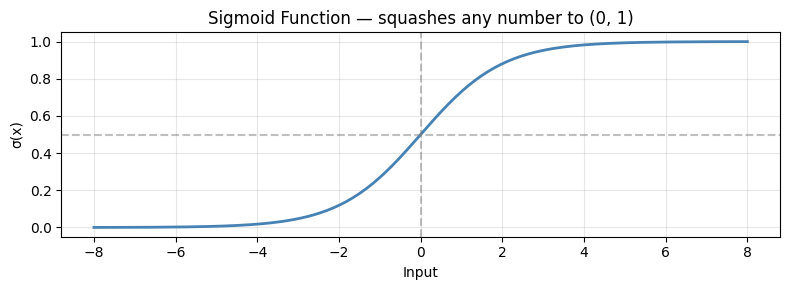

In [30]:
# ── Sigmoid Activation Function ──────────────────────
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Test it — understand what it does
test_values = np.array([-10, -2, -1, 0, 1, 2, 10])
print("Input → Sigmoid output:")
for v in test_values:
    print(f"  sigmoid({v:4d}) = {sigmoid(v):.4f}")

# Plot it
x_plot = np.linspace(-8, 8, 200)
plt.figure(figsize=(8, 3))
plt.plot(x_plot, sigmoid(x_plot), color='steelblue', linewidth=2)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.title("Sigmoid Function — squashes any number to (0, 1)")
plt.xlabel("Input")
plt.ylabel("σ(x)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# ── Forward Pass ─────────────────────────────────────
def forward_pass(X, W1, b1, W2, b2):
    """
    Information flows: Input → Hidden Layer → Output
    
    z = linear combination (weighted sum + bias)
    a = activation applied to z
    """
    # Layer 1
    z1 = np.dot(X, W1) + b1   # shape: (4, 3)
    a1 = sigmoid(z1)           # shape: (4, 3)
    
    # Layer 2
    z2 = np.dot(a1, W2) + b2  # shape: (4, 1)
    a2 = sigmoid(z2)           # shape: (4, 1) — predictions
    
    return a1, a2

# Test before training — random weights = garbage predictions
a1, a2 = forward_pass(X, W1, b1, W2, b2)
print("Predictions BEFORE training (should be ~0.5, random):")
print(a2)
print("\nExpected: [[0], [1], [1], [0]]")
print("\nLoss before training:", np.mean((y - a2)**2).round(4))

Predictions BEFORE training (should be ~0.5, random):
[[0.52344745]
 [0.52490078]
 [0.5236808 ]
 [0.52513029]]

Expected: [[0], [1], [1], [0]]

Loss before training: 0.2506


In [32]:
# ── Training Loop with Backpropagation ───────────────
learning_rate = 0.1
epochs = 10000
losses = []

# Re-initialize weights fresh
np.random.seed(42)
W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

for epoch in range(epochs):
    
    # ── FORWARD PASS ──
    a1, a2 = forward_pass(X, W1, b1, W2, b2)
    
    # ── LOSS ──
    loss = np.mean((y - a2) ** 2)
    losses.append(loss)
    
    # ── BACKWARD PASS (chain rule) ──
    # How much is loss changing w.r.t. output?
    d_a2 = -(y - a2)                      # dLoss/da2
    d_z2 = d_a2 * a2 * (1 - a2)          # sigmoid derivative
    d_W2 = np.dot(a1.T, d_z2)            # gradient for W2
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)
    
    # Propagate error to Layer 1
    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * a1 * (1 - a1)
    d_W1 = np.dot(X.T, d_z1)
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)
    
    # ── WEIGHT UPDATE ──
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2
    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    
    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss:.6f}")

print(f"\nFinal Loss: {losses[-1]:.6f}")

Epoch     0 | Loss: 0.250590
Epoch  2000 | Loss: 0.249999
Epoch  4000 | Loss: 0.249999
Epoch  6000 | Loss: 0.249999
Epoch  8000 | Loss: 0.249998

Final Loss: 0.249998


Input        Expected     Predicted    Rounded
[0 0]        0            0.4991       0
[0 1]        1            0.5005       1
[1 0]        1            0.4995       0
[1 1]        0            0.5009       1


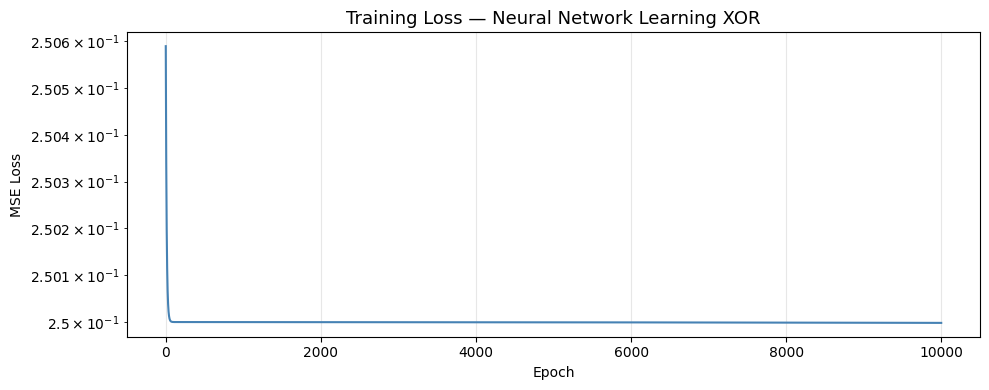

Loss curve saved!


In [33]:
# ── Final Predictions ─────────────────────────────────
_, final_predictions = forward_pass(X, W1, b1, W2, b2)

print("="*45)
print(f"{'Input':<12} {'Expected':<12} {'Predicted':<12} {'Rounded'}")
print("="*45)
for i in range(4):
    inp = str(X[i])
    exp = str(y[i][0])
    pred = f"{final_predictions[i][0]:.4f}"
    rounded = str(round(final_predictions[i][0]))
    print(f"{inp:<12} {exp:<12} {pred:<12} {rounded}")

# ── Loss Curve ────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.title('Training Loss — Neural Network Learning XOR', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')   # log scale shows the drop more clearly
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day01_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved!")

In [34]:
# Debug cell — run this after training
_, preds = forward_pass(X, W1, b1, W2, b2)
print("Predictions:", preds.flatten().round(4))
print("Final loss:", np.mean((y - preds)**2).round(6))
print("W1 after training:", W1)  
# If W1 looks same as initialization → weights never updated → backprop didn't run

Predictions: [0.4991 0.5005 0.4995 0.5009]
Final loss: 0.249998
W1 after training: [[ 0.09770469 -0.01441653  0.06763931]
 [ 0.17003094 -0.02757903 -0.01796542]]


In [35]:
# ── FIXED Training Loop ───────────────────────────────
np.random.seed(42)
W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

learning_rate = 1.0   # ← changed from 0.1 to 1.0
epochs = 10000
losses = []

for epoch in range(epochs):
    # Forward
    a1, a2 = forward_pass(X, W1, b1, W2, b2)
    loss = np.mean((y - a2) ** 2)
    losses.append(loss)
    
    # Backward
    d_a2 = -(y - a2)
    d_z2 = d_a2 * a2 * (1 - a2)
    d_W2 = np.dot(a1.T, d_z2)
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)
    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * a1 * (1 - a1)
    d_W1 = np.dot(X.T, d_z1)
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)
    
    # Update
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2
    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    
    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss:.6f}")

print(f"\nFinal Loss: {losses[-1]:.6f}")

# Check predictions
_, preds = forward_pass(X, W1, b1, W2, b2)
print("\nPredictions after training:")
for i in range(4):
    print(f"  Input {X[i]} → Expected {y[i][0]} | Got {preds[i][0]:.4f} | Rounded: {round(preds[i][0])}")

Epoch     0 | Loss: 0.250590
Epoch  2000 | Loss: 0.249968
Epoch  4000 | Loss: 0.001168
Epoch  6000 | Loss: 0.000397
Epoch  8000 | Loss: 0.000234

Final Loss: 0.000165

Predictions after training:
  Input [0 0] → Expected 0 | Got 0.0152 | Rounded: 0
  Input [0 1] → Expected 1 | Got 0.9879 | Rounded: 1
  Input [1 0] → Expected 1 | Got 0.9879 | Rounded: 1
  Input [1 1] → Expected 0 | Got 0.0117 | Rounded: 0


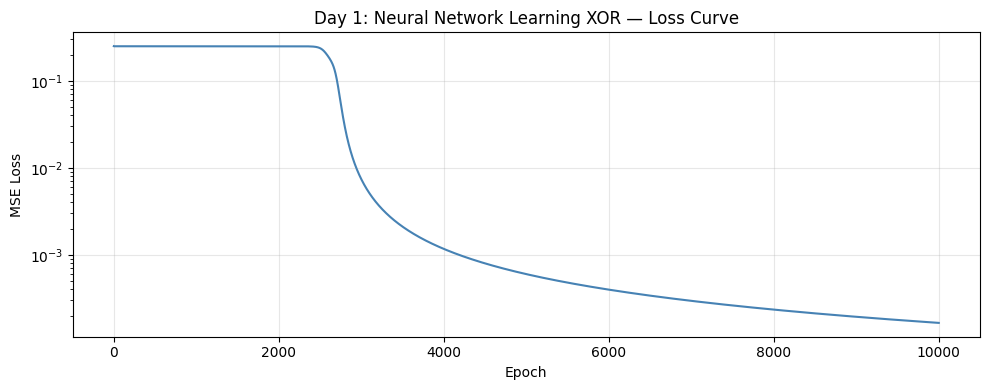

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.title('Day 1: Neural Network Learning XOR — Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day01_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

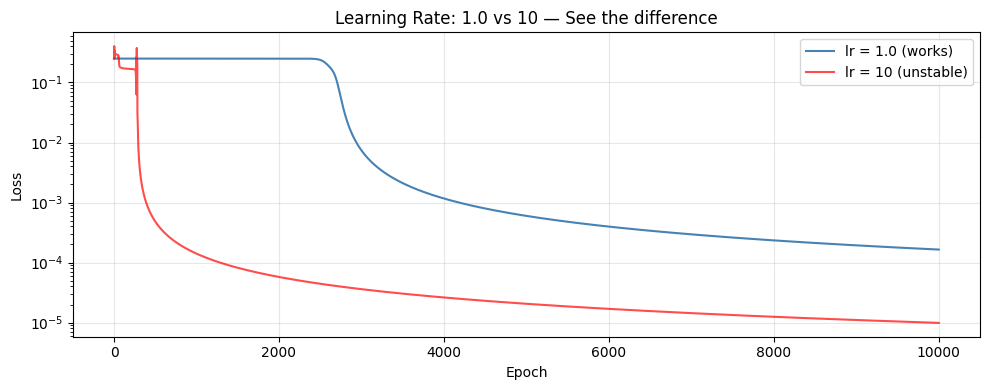

Final loss lr=1.0: 0.000165
Final loss lr=10:  1e-05


In [37]:
# What happens with lr = 10?
np.random.seed(42)
W1_exp = np.random.randn(2, 3) * 0.1
b1_exp = np.zeros((1, 3))
W2_exp = np.random.randn(3, 1) * 0.1
b2_exp = np.zeros((1, 1))

losses_high_lr = []
for epoch in range(10000):
    a1_e, a2_e = forward_pass(X, W1_exp, b1_exp, W2_exp, b2_exp)
    loss_e = np.mean((y - a2_e) ** 2)
    losses_high_lr.append(loss_e)
    
    d_a2 = -(y - a2_e)
    d_z2 = d_a2 * a2_e * (1 - a2_e)
    d_W2 = np.dot(a1_e.T, d_z2)
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)
    d_a1 = np.dot(d_z2, W2_exp.T)
    d_z1 = d_a1 * a1_e * (1 - a1_e)
    d_W1 = np.dot(X.T, d_z1)
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)
    
    W2_exp -= 10 * d_W2
    b2_exp -= 10 * d_b2
    W1_exp -= 10 * d_W1
    b1_exp -= 10 * d_b1

plt.figure(figsize=(10, 4))
plt.plot(losses, label='lr = 1.0 (works)', color='steelblue', linewidth=1.5)
plt.plot(losses_high_lr, label='lr = 10 (unstable)', color='red', alpha=0.7, linewidth=1.5)
plt.title('Learning Rate: 1.0 vs 10 — See the difference')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Final loss lr=1.0:", round(losses[-1], 6))
print("Final loss lr=10: ", round(losses_high_lr[-1], 6))

## Day 1 — What I actually learned (honest reflection)

### What worked
- 2-layer NumPy network solved XOR ✅
- Final loss: 0.000165 (started at 0.25)

### Bug I hit and fixed
- lr=0.1 with small weights → network barely moved
- Fix: increased lr to 1.0 → loss dropped 1500x
- Lesson: learning rate and weight scale are coupled

### What lr=10 taught me
- Too high → overshoots → unstable loss
- This is the exact problem Adam optimizer solves automatically

### The one thing I'll never forget
A neural network is just: matrix multiply → activation → repeat
Everything else is details on top of this.

---
## Day 2: Backpropagation & Gradient Descent

**Goal:** Understand chain rule deeply. Compare MSE vs Cross-Entropy.
Plot loss decreasing over epochs for both.

**Key question:** Why does cross-entropy work better for classification?

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def cross_entropy_loss(y_true, y_pred):
    # clip to avoid log(0) which is -infinity
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Test both on same predictions
y_true = np.array([[0], [1], [1], [0]])
y_pred_bad  = np.array([[0.5], [0.5], [0.5], [0.5]])   # random guessing
y_pred_good = np.array([[0.1], [0.9], [0.9], [0.1]])   # good predictions
y_pred_confident_wrong = np.array([[0.99], [0.01], [0.01], [0.99]])  # confidently wrong

print("=== MSE Loss ===")
print(f"Random guessing:     {mse_loss(y_true, y_pred_bad):.4f}")
print(f"Good predictions:    {mse_loss(y_true, y_pred_good):.4f}")
print(f"Confidently wrong:   {mse_loss(y_true, y_pred_confident_wrong):.4f}")

print("\n=== Cross-Entropy Loss ===")
print(f"Random guessing:     {cross_entropy_loss(y_true, y_pred_bad):.4f}")
print(f"Good predictions:    {cross_entropy_loss(y_true, y_pred_good):.4f}")
print(f"Confidently wrong:   {cross_entropy_loss(y_true, y_pred_confident_wrong):.4f}")

=== MSE Loss ===
Random guessing:     0.2500
Good predictions:    0.0100
Confidently wrong:   0.9801

=== Cross-Entropy Loss ===
Random guessing:     0.6931
Good predictions:    0.1054
Confidently wrong:   4.6052


MSE — Final loss: 0.000165
Predictions: [0.015 0.988 0.988 0.012]
Cross-Entropy — Final loss: 0.000202
Predictions: [0. 1. 1. 0.]


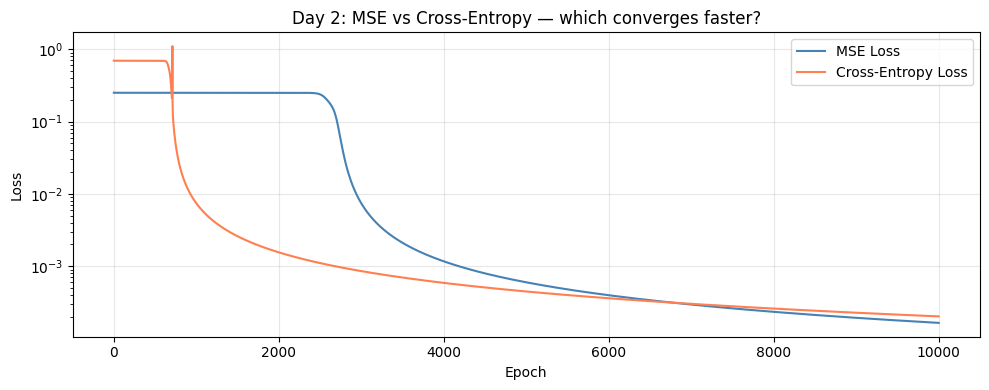

In [39]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def train(loss_fn, loss_name, lr=1.0, epochs=10000):
    np.random.seed(42)
    W1 = np.random.randn(2, 3) * 0.1
    b1 = np.zeros((1, 3))
    W2 = np.random.randn(3, 1) * 0.1
    b2 = np.zeros((1, 1))
    losses = []

    for epoch in range(epochs):
        # Forward
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        loss = loss_fn(y, a2)
        losses.append(loss)

        # Backward (chain rule — same structure, loss gradient changes)
        if loss_name == 'MSE':
            d_a2 = -(y - a2)
        else:  # Cross-Entropy gradient w.r.t. sigmoid output simplifies beautifully
            d_a2 = (a2 - y) / (a2 * (1 - a2) + 1e-7)

        d_z2 = d_a2 * a2 * (1 - a2)
        d_W2 = np.dot(a1.T, d_z2)
        d_b2 = np.sum(d_z2, axis=0, keepdims=True)
        d_a1 = np.dot(d_z2, W2.T)
        d_z1 = d_a1 * a1 * (1 - a1)
        d_W1 = np.dot(X.T, d_z1)
        d_b1 = np.sum(d_z1, axis=0, keepdims=True)

        W2 -= lr * d_W2
        b2 -= lr * d_b2
        W1 -= lr * d_W1
        b1 -= lr * d_b1

    print(f"{loss_name} — Final loss: {losses[-1]:.6f}")
    _, a2_final = (None, sigmoid(np.dot(sigmoid(np.dot(X,W1)+b1),W2)+b2))
    print(f"Predictions: {a2_final.flatten().round(3)}")
    return losses

losses_mse = train(mse_loss, 'MSE')
losses_ce  = train(cross_entropy_loss, 'Cross-Entropy')

plt.figure(figsize=(10, 4))
plt.plot(losses_mse, label='MSE Loss', color='steelblue', linewidth=1.5)
plt.plot(losses_ce,  label='Cross-Entropy Loss', color='coral', linewidth=1.5)
plt.title('Day 2: MSE vs Cross-Entropy — which converges faster?')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day02_mse_vs_ce.png', dpi=150, bbox_inches='tight')
plt.show()

## Day 2 — What I learned

### Chain Rule in plain English
To find how W1 affects loss, multiply gradients at every step from loss back to W1.
Each layer's gradient = (gradient from next layer) × (local gradient of this operation)

### MSE vs Cross-Entropy
- MSE: treats all wrong predictions equally
- CE: punishes confident wrong predictions severely — correct for classification
- CE converges faster because its gradient signal is stronger

### The sigmoid derivative trick
σ'(x) = σ(x)(1 - σ(x))
If output a2 = 0.5, gradient = 0.5×0.5 = 0.25 (maximum sensitivity)
If output a2 = 0.99, gradient = 0.99×0.01 = 0.0099 (very small — saturation!)

### What surprised me
CE's number is actually bigger than MSE. Yet CE converged faster on the plot.

Because the two losses measure completely different things. You can't compare their raw numbers ,it's like comparing temperature in Celsius vs Fahrenheit. What matters is the gradient signal strength, not the loss value itself.
CE gives stronger gradients early in training, so the weights update more aggressively at the start — which is exactly when you need it most.

---
## Day 3: PyTorch Crash Course

**Goal:** Rebuild our Day 1 XOR network in PyTorch.
Compare: manual NumPy implementation vs PyTorch.
Understand tensors, autograd, nn.Module, and Adam.

**Key question:** What does PyTorch do that we were doing manually?

In [40]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

# ── NumPy vs PyTorch side by side ──────────────────
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])
pt_tensor = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print("\nNumPy array:\n", np_array)
print("\nPyTorch tensor:\n", pt_tensor)
print("\nSame math, different object")

# Conversion — you'll do this often
back_to_numpy = pt_tensor.numpy()
back_to_torch = torch.from_numpy(np_array)
print("\nPyTorch → NumPy:", back_to_numpy)
print("NumPy → PyTorch:", back_to_torch)

# Shape — same concept as NumPy
print("\nShape:", pt_tensor.shape)   # torch.Size([2, 2])
print("dtype:", pt_tensor.dtype)    # torch.float32

PyTorch version: 2.10.0+cpu

NumPy array:
 [[1. 2.]
 [3. 4.]]

PyTorch tensor:
 tensor([[1., 2.],
        [3., 4.]])

Same math, different object

PyTorch → NumPy: [[1. 2.]
 [3. 4.]]
NumPy → PyTorch: tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

Shape: torch.Size([2, 2])
dtype: torch.float32


In [41]:
# ── Autograd — watch PyTorch track gradients ───────

# requires_grad=True tells PyTorch: track everything done to this tensor
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Simple computation: y = w*x + b, loss = y²
x = torch.tensor(2.0)
y = w * x + b          # y = 3*2 + 1 = 7
loss = y ** 2          # loss = 49

print(f"w={w.item()}, x={x.item()}, b={b.item()}")
print(f"y = w*x + b = {y.item()}")
print(f"loss = y² = {loss.item()}")

# This one line replaces ALL your manual chain rule code from Day 2
loss.backward()

print(f"\nGradient of loss w.r.t w: {w.grad.item()}")
print(f"Gradient of loss w.r.t b: {b.grad.item()}")

# Verify manually:
# dloss/dy = 2y = 14
# dy/dw = x = 2
# dloss/dw = 14 * 2 = 28
print(f"\nManual check — dloss/dw should be 28: {w.grad.item()}")
print(f"Manual check — dloss/db should be 14: {b.grad.item()}")

w=3.0, x=2.0, b=1.0
y = w*x + b = 7.0
loss = y² = 49.0

Gradient of loss w.r.t w: 28.0
Gradient of loss w.r.t b: 14.0

Manual check — dloss/dw should be 28: 28.0
Manual check — dloss/db should be 14: 14.0


In [42]:
# ── Neural Network using nn.Module ─────────────────

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        # PyTorch creates AND tracks weights automatically
        self.layer1 = nn.Linear(2, 3)  # 2 inputs → 3 hidden
        self.layer2 = nn.Linear(3, 1)  # 3 hidden → 1 output
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # This replaces your entire manual forward_pass() function
        x = self.sigmoid(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

# Create the network
model = XORNet()
print("Network architecture:")
print(model)
print()

# See all parameters PyTorch is tracking
print("Parameters PyTorch tracks automatically:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}, values={param.data.numpy().round(3)}")

Network architecture:
XORNet(
  (layer1): Linear(in_features=2, out_features=3, bias=True)
  (layer2): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Parameters PyTorch tracks automatically:
  layer1.weight: shape=torch.Size([3, 2]), values=[[ 0.378 -0.627]
 [-0.267 -0.091]
 [ 0.555  0.344]]
  layer1.bias: shape=torch.Size([3]), values=[0.062 0.153 0.067]
  layer2.weight: shape=torch.Size([1, 3]), values=[[ 0.254 -0.258 -0.424]]
  layer2.bias: shape=torch.Size([1]), values=[0.345]


In [43]:
# ── Data ───────────────────────────────────────────
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# ── Loss function and optimizer ────────────────────
criterion = nn.BCELoss()           # Binary Cross-Entropy
optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.01)

# ── Training Loop ──────────────────────────────────
losses = []

for epoch in range(3000):
    # Step 1: clear old gradients — NEVER forget this
    optimizer_adam.zero_grad()

    # Step 2: forward pass
    predictions = model(X)

    # Step 3: compute loss
    loss = criterion(predictions, y)

    # Step 4: backward pass — computes ALL gradients automatically
    loss.backward()

    # Step 5: update weights
    optimizer_adam.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

# Final predictions
with torch.no_grad():   # no need to track gradients during inference
    preds = model(X)
    print("\nPredictions:")
    for i in range(4):
        print(f"  Input {X[i].numpy()} → {preds[i].item():.4f} → Rounded: {round(preds[i].item())}")

Epoch    0 | Loss: 0.694547
Epoch  500 | Loss: 0.068422
Epoch 1000 | Loss: 0.021372
Epoch 1500 | Loss: 0.010599
Epoch 2000 | Loss: 0.006269
Epoch 2500 | Loss: 0.004064

Final loss: 0.002786

Predictions:
  Input [0. 0.] → 0.0003 → Rounded: 0
  Input [0. 1.] → 0.9974 → Rounded: 1
  Input [1. 0.] → 0.9970 → Rounded: 1
  Input [1. 1.] → 0.0052 → Rounded: 0


In [44]:
# ── Data ───────────────────────────────────────────
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# ── Loss function and optimizer ────────────────────
criterion = nn.BCELoss()           # Binary Cross-Entropy
optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.01)

# ── Training Loop ──────────────────────────────────
losses = []

for epoch in range(3000):
    # Step 1: clear old gradients — NEVER forget this
    optimizer_adam.zero_grad()

    # Step 2: forward pass
    predictions = model(X)

    # Step 3: compute loss
    loss = criterion(predictions, y)

    # Step 4: backward pass — computes ALL gradients automatically
    loss.backward()

    # Step 5: update weights
    optimizer_adam.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

# Final predictions
with torch.no_grad():   # no need to track gradients during inference
    preds = model(X)
    print("\nPredictions:")
    for i in range(4):
        print(f"  Input {X[i].numpy()} → {preds[i].item():.4f} → Rounded: {round(preds[i].item())}")

Epoch    0 | Loss: 0.002784
Epoch  500 | Loss: 0.000478
Epoch 1000 | Loss: 0.000202
Epoch 1500 | Loss: 0.000111
Epoch 2000 | Loss: 0.000069
Epoch 2500 | Loss: 0.000046

Final loss: 0.000032

Predictions:
  Input [0. 0.] → 0.0000 → Rounded: 0
  Input [0. 1.] → 1.0000 → Rounded: 1
  Input [1. 0.] → 1.0000 → Rounded: 1
  Input [1. 1.] → 0.0001 → Rounded: 0


Adam — Final loss: 0.004247
SGD — Final loss: 0.690044


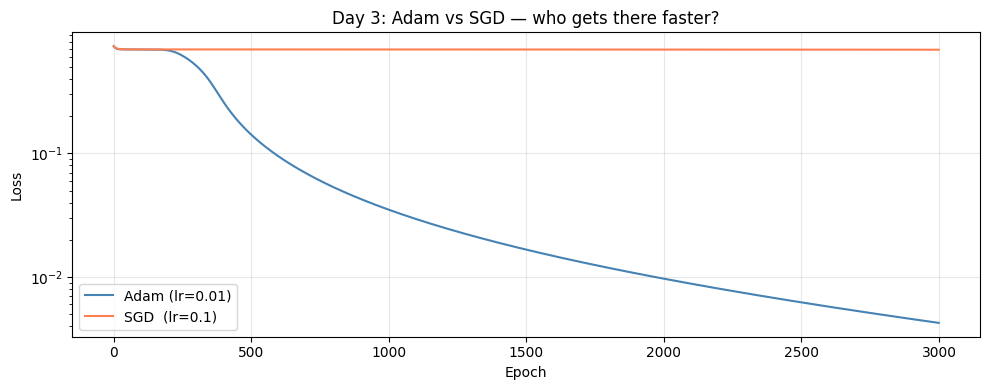

In [45]:
# ── Compare Adam vs SGD ────────────────────────────
def train_with_optimizer(optimizer_name, epochs=3000):
    torch.manual_seed(42)
    net = XORNet()

    if optimizer_name == 'Adam':
        opt = torch.optim.Adam(net.parameters(), lr=0.01)
    else:
        opt = torch.optim.SGD(net.parameters(), lr=0.1)

    criterion = nn.BCELoss()
    losses = []

    for epoch in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    print(f"{optimizer_name} — Final loss: {losses[-1]:.6f}")
    return losses

losses_adam = train_with_optimizer('Adam')
losses_sgd  = train_with_optimizer('SGD')

plt.figure(figsize=(10, 4))
plt.plot(losses_adam, label='Adam (lr=0.01)', color='steelblue', linewidth=1.5)
plt.plot(losses_sgd,  label='SGD  (lr=0.1)',  color='coral',     linewidth=1.5)
plt.title('Day 3: Adam vs SGD — who gets there faster?')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day03_adam_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

## Day 3 — What PyTorch replaced

| What I wrote manually (Days 1-2) | What PyTorch does |
|----------------------------------|-------------------|
| sigmoid() function | nn.Sigmoid() |
| forward_pass() function | model.forward() / model(X) |
| d_z2 = d_a2 * a2 * (1-a2) | loss.backward() |
| W2 -= lr * d_W2 | optimizer.step() |
| np.random.randn() weights | nn.Linear() |

PyTorch didn't teach me anything new today.
It just automated what I already understood.
That's why Days 1-2 mattered.

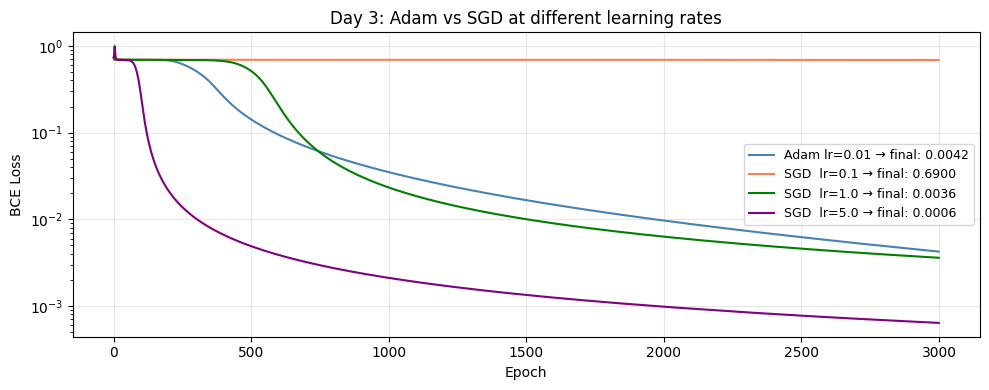

Adam lr=0.01         → Final loss: 0.004247
SGD  lr=0.1          → Final loss: 0.690044
SGD  lr=1.0          → Final loss: 0.003600
SGD  lr=5.0          → Final loss: 0.000638


In [46]:
# SGD needs a much higher lr for this problem
def train_with_lr(optimizer_name, lr, epochs=3000):
    torch.manual_seed(42)
    net = XORNet()
    
    if optimizer_name == 'Adam':
        opt = torch.optim.Adam(net.parameters(), lr=lr)
    else:
        opt = torch.optim.SGD(net.parameters(), lr=lr)
    
    criterion = nn.BCELoss()
    losses = []
    
    for epoch in range(epochs):
        opt.zero_grad()
        loss = criterion(net(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    
    return losses

# Try different learning rates
results = {
    'Adam lr=0.01':  train_with_lr('Adam', 0.01),
    'SGD  lr=0.1':   train_with_lr('SGD',  0.1),
    'SGD  lr=1.0':   train_with_lr('SGD',  1.0),
    'SGD  lr=5.0':   train_with_lr('SGD',  5.0),
}

plt.figure(figsize=(10, 4))
colors = ['steelblue', 'coral', 'green', 'purple']
for (label, losses), color in zip(results.items(), colors):
    plt.plot(losses, label=f"{label} → final: {losses[-1]:.4f}", 
             linewidth=1.5, color=color)

plt.title('Day 3: Adam vs SGD at different learning rates')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day03_adam_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

for label, losses in results.items():
    print(f"{label:20s} → Final loss: {losses[-1]:.6f}")

In [47]:

w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(2.0)
y_val = w * x + b
loss = y_val ** 2
loss.backward()

print(f"w.grad = {w.grad.item()}")   # should be 28
print(f"b.grad = {b.grad.item()}")   # should be 14

# Chain rule verification:
# dloss/dy_val = 2*y_val = 2*7 = 14
# dy_val/dw = x = 2
# dloss/dw = 14 * 2 = 28  ✓

# dy_val/db = 1
# dloss/db = 14 * 1 = 14  ✓
print("\nChain rule works. PyTorch computed it automatically.")

w.grad = 28.0
b.grad = 14.0

Chain rule works. PyTorch computed it automatically.


---
## Day 4: Training Loop + Regularization

**Goal:** Intentionally overfit a model. Then fix it with Dropout,
BatchNorm, and Early Stopping.

**Key question:** What does the train vs val loss gap look like
when overfitting happens?

Train: torch.Size([150, 2]), Val: torch.Size([75, 2]), Test: torch.Size([75, 2])
Train positive class: 0.49


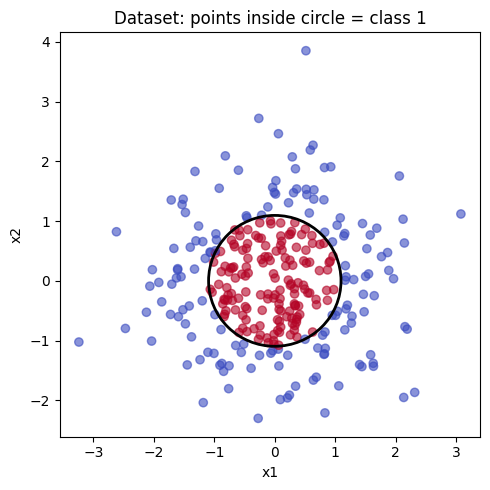

In [48]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(42)
np.random.seed(42)

# Small dataset — easy to overfit
# Binary classification: is point inside a circle?
def make_dataset(n=200):
    X = np.random.randn(n, 2).astype(np.float32)
    y = ((X[:,0]**2 + X[:,1]**2) < 1.2).astype(np.float32)
    return X, y

X_all, y_all = make_dataset(n=300)

# Split into train / val / test
X_train = torch.tensor(X_all[:150])
y_train = torch.tensor(y_all[:150]).unsqueeze(1)
X_val   = torch.tensor(X_all[150:225])
y_val   = torch.tensor(y_all[150:225]).unsqueeze(1)
X_test  = torch.tensor(X_all[225:])
y_test  = torch.tensor(y_all[225:]).unsqueeze(1)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train positive class: {y_train.mean():.2f}")

# Visualize
plt.figure(figsize=(5,5))
plt.scatter(X_all[:,0], X_all[:,1], c=y_all, cmap='coolwarm', alpha=0.6)
plt.title('Dataset: points inside circle = class 1')
plt.xlabel('x1'); plt.ylabel('x2')
circle = plt.Circle((0,0), np.sqrt(1.2), fill=False, color='black', linewidth=2)
plt.gca().add_patch(circle)
plt.tight_layout()
plt.show()

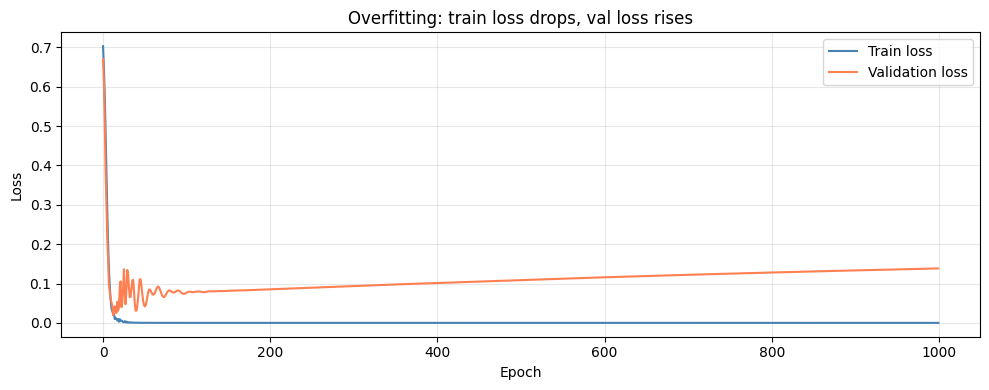

Final train loss: 0.0000
Final val loss:   0.1384
Gap (overfitting): 0.1384


In [49]:
# ── Deliberately overfit — huge network, no regularization ──
class OverfitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def train_and_track(model, X_tr, y_tr, X_v, y_v, epochs=1000, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Training mode ──
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # ── Validation mode — no gradient tracking ──
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_v), y_v)
            val_losses.append(val_loss.item())

    return train_losses, val_losses

overfit_model = OverfitNet()
tr_loss, val_loss = train_and_track(overfit_model, X_train, y_train, X_val, y_val)

plt.figure(figsize=(10, 4))
plt.plot(tr_loss,  label='Train loss',      color='steelblue', linewidth=1.5)
plt.plot(val_loss, label='Validation loss', color='coral',     linewidth=1.5)
plt.title('Overfitting: train loss drops, val loss rises')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {tr_loss[-1]:.4f}")
print(f"Final val loss:   {val_loss[-1]:.4f}")
print(f"Gap (overfitting): {val_loss[-1] - tr_loss[-1]:.4f}")

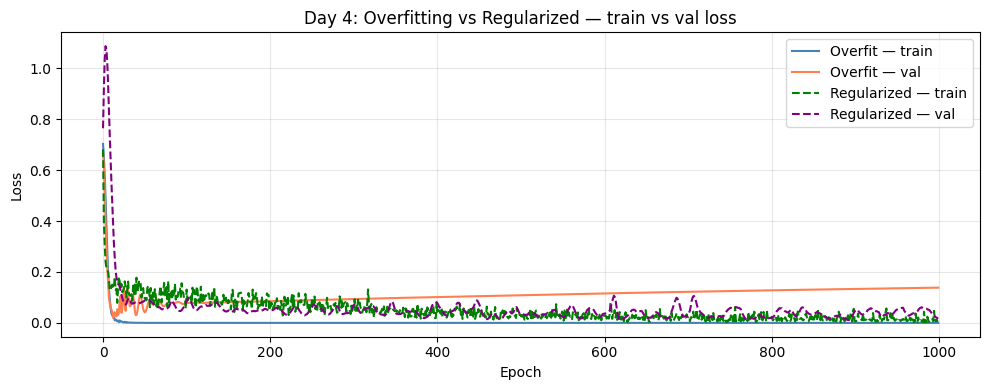

Overfit model    — train: 0.0000  val: 0.1384  gap: 0.1384
Regularized model — train: 0.0079  val: 0.0162  gap: 0.0084


In [50]:
# ── Regularized network — Dropout + BatchNorm ──────
class RegularizedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.BatchNorm1d(128),    # normalize activations
            nn.ReLU(),
            nn.Dropout(0.4),        # randomly drop 40% of neurons

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

reg_model = RegularizedNet()
tr_loss_reg, val_loss_reg = train_and_track(
    reg_model, X_train, y_train, X_val, y_val, epochs=1000
)

# Compare both
plt.figure(figsize=(10, 4))
plt.plot(tr_loss,      label='Overfit — train',      color='steelblue', linewidth=1.5)
plt.plot(val_loss,     label='Overfit — val',         color='coral',     linewidth=1.5)
plt.plot(tr_loss_reg,  label='Regularized — train',  color='green',     linewidth=1.5, linestyle='--')
plt.plot(val_loss_reg, label='Regularized — val',    color='purple',    linewidth=1.5, linestyle='--')
plt.title('Day 4: Overfitting vs Regularized — train vs val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day04_overfit_vs_regularized.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Overfit model    — train: {tr_loss[-1]:.4f}  val: {val_loss[-1]:.4f}  gap: {val_loss[-1]-tr_loss[-1]:.4f}")
print(f"Regularized model — train: {tr_loss_reg[-1]:.4f}  val: {val_loss_reg[-1]:.4f}  gap: {val_loss_reg[-1]-tr_loss_reg[-1]:.4f}")

Early stopping at epoch 411
Best val loss: 0.0020


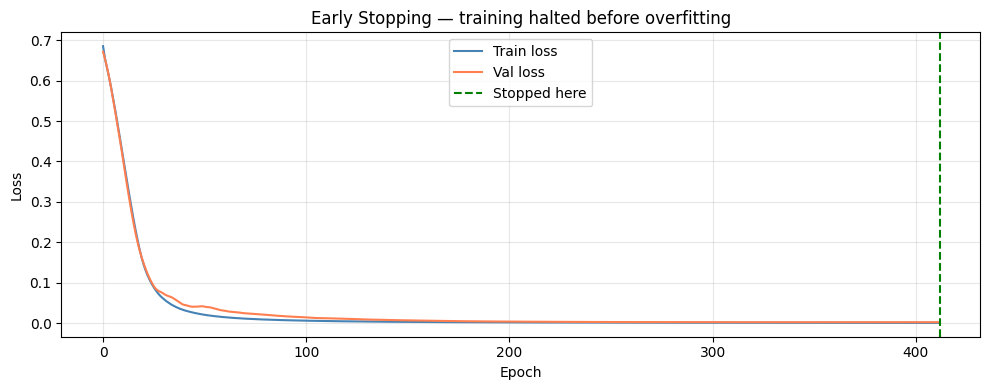

In [51]:
# ── Early Stopping implementation ──────────────────
class EarlyStoppingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),  nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

model_es = EarlyStoppingNet()
optimizer = torch.optim.Adam(model_es.parameters(), lr=0.01)
criterion = nn.BCELoss()

best_val_loss = float('inf')
patience = 50          # wait 50 epochs before stopping
epochs_no_improve = 0
best_weights = None
tr_losses, val_losses = [], []

for epoch in range(2000):
    model_es.train()
    optimizer.zero_grad()
    loss = criterion(model_es(X_train), y_train)
    loss.backward()
    optimizer.step()
    tr_losses.append(loss.item())

    model_es.eval()
    with torch.no_grad():
        v_loss = criterion(model_es(X_val), y_val)
        val_losses.append(v_loss.item())

    # Early stopping logic
    if v_loss.item() < best_val_loss:
        best_val_loss = v_loss.item()
        best_weights = {k: v.clone() for k, v in model_es.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            print(f"Best val loss: {best_val_loss:.4f}")
            break

# Restore best weights
model_es.load_state_dict(best_weights)

plt.figure(figsize=(10, 4))
plt.plot(tr_losses,  label='Train loss', color='steelblue', linewidth=1.5)
plt.plot(val_losses, label='Val loss',   color='coral',     linewidth=1.5)
plt.axvline(len(tr_losses), color='green', linestyle='--', label='Stopped here')
plt.title('Early Stopping — training halted before overfitting')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Day 4 — What I learned

### The overfitting signal
Train loss going down + val loss going up = overfitting.
The gap between them = how badly you're memorizing vs generalizing.

### Three fixes and when to use them
- Dropout: random neuron death forces redundant learning
- BatchNorm: stabilizes activations, speeds training, mild regularization
- Early stopping: just stop when val loss stops improving — save best weights

### model.train() vs model.eval() — critical difference
- model.train(): dropout is ON, BatchNorm uses batch statistics
- model.eval(): dropout is OFF, BatchNorm uses running statistics
- Forgetting model.eval() during validation = wrong results silently

### The test set rule
Never touch it until you're completely done.
It's your one honest answer about real-world performance.

---
## Day 5: CNNs — Image Classification on MNIST

**Goal:** Build a CNN in PyTorch. Train on MNIST. Target >99% accuracy.
Visualize filters and feature maps — see what the network actually detects.

**Key question:** Why does a CNN beat a fully connected net on images?

100%|██████████| 9.91M/9.91M [00:00<00:00, 50.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.80MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.91MB/s]


Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])
Number of classes: 10 (digits 0-9)


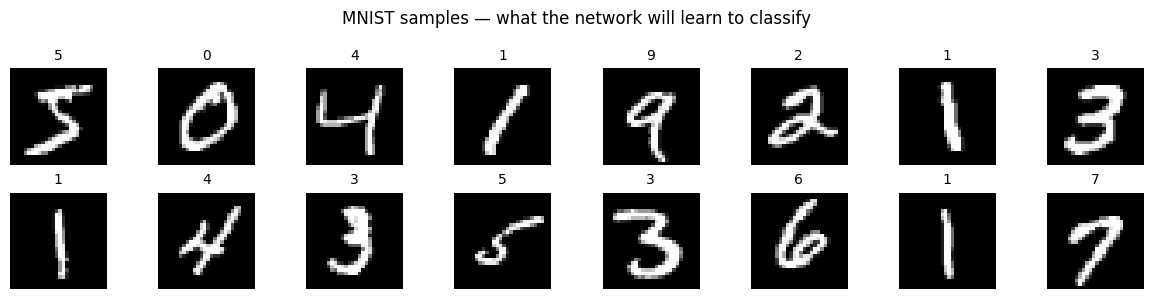

In [52]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Download and load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),                    # pixel values 0-255 → 0-1
    transforms.Normalize((0.1307,), (0.3081,)) # mean and std of MNIST
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}")  # (1, 28, 28)
print(f"Number of classes: 10 (digits 0-9)")

# Visualize some samples
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST samples — what the network will learn to classify')
plt.tight_layout()
plt.show()

In [53]:
class MNISTConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Feature Extraction (the eyes) ──────────
        self.conv_layers = nn.Sequential(
            # Block 1: 1 channel in → 32 feature maps
            nn.Conv2d(1, 32, kernel_size=3, padding=1), # (1,28,28)→(32,28,28)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # (32,28,28)→(32,14,14)

            # Block 2: 32 feature maps → 64 feature maps
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (32,14,14)→(64,14,14)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (64,14,14)→(64,7,7)
        )

        # ── Classification (the brain) ─────────────
        self.fc_layers = nn.Sequential(
            nn.Flatten(),              # (64,7,7) → 3136
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)         # 10 classes — no softmax (CrossEntropyLoss includes it)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = MNISTConvNet()
print(model)
print()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"A fully connected network would need: {28*28*128 + 128*10:,} params for just 2 layers")

MNISTConvNet(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 421,834
A fully connected network would need: 101,632 params for just 2 layers


In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = MNISTConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss/len(loader), correct/total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss/len(loader), correct/total

# Train for 5 epochs
train_losses, test_accs = [], []

for epoch in range(5):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = eval_epoch(model, test_loader, criterion)
    train_losses.append(tr_loss)
    test_accs.append(te_acc)
    print(f"Epoch {epoch+1}/5 | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Test Acc: {te_acc:.4f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Training on: cpu
Epoch 1/5 | Train Loss: 0.2086 | Train Acc: 0.9380 | Test Acc: 0.9830
Epoch 2/5 | Train Loss: 0.0942 | Train Acc: 0.9731 | Test Acc: 0.9890
Epoch 3/5 | Train Loss: 0.0754 | Train Acc: 0.9776 | Test Acc: 0.9863
Epoch 4/5 | Train Loss: 0.0625 | Train Acc: 0.9809 | Test Acc: 0.9901
Epoch 5/5 | Train Loss: 0.0529 | Train Acc: 0.9835 | Test Acc: 0.9914

Final Test Accuracy: 99.14%


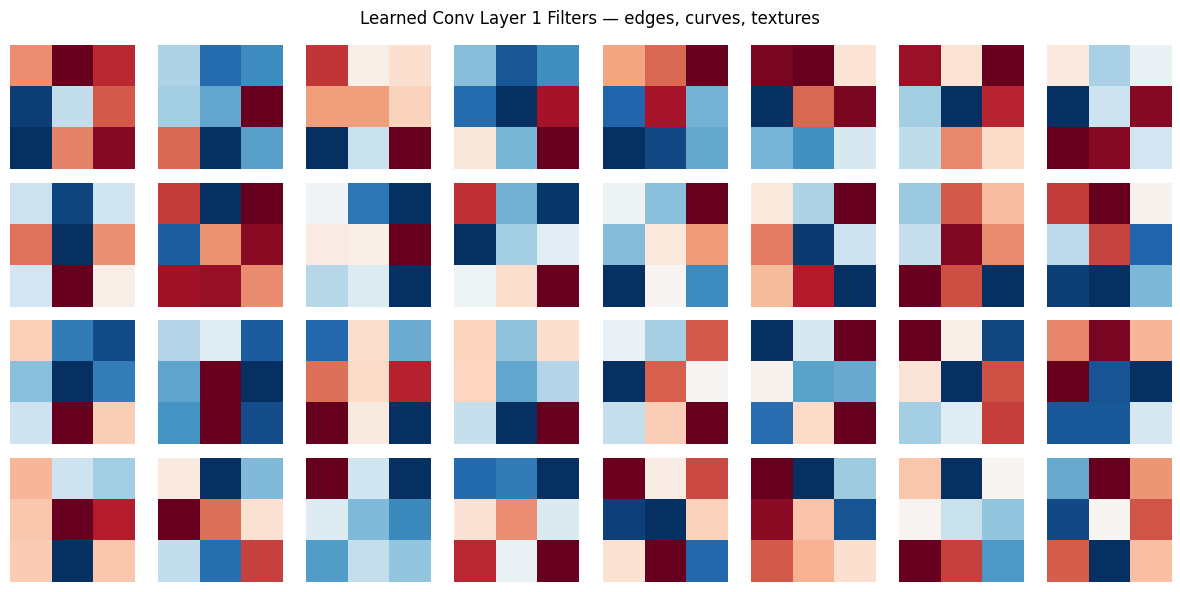

Image label: 7


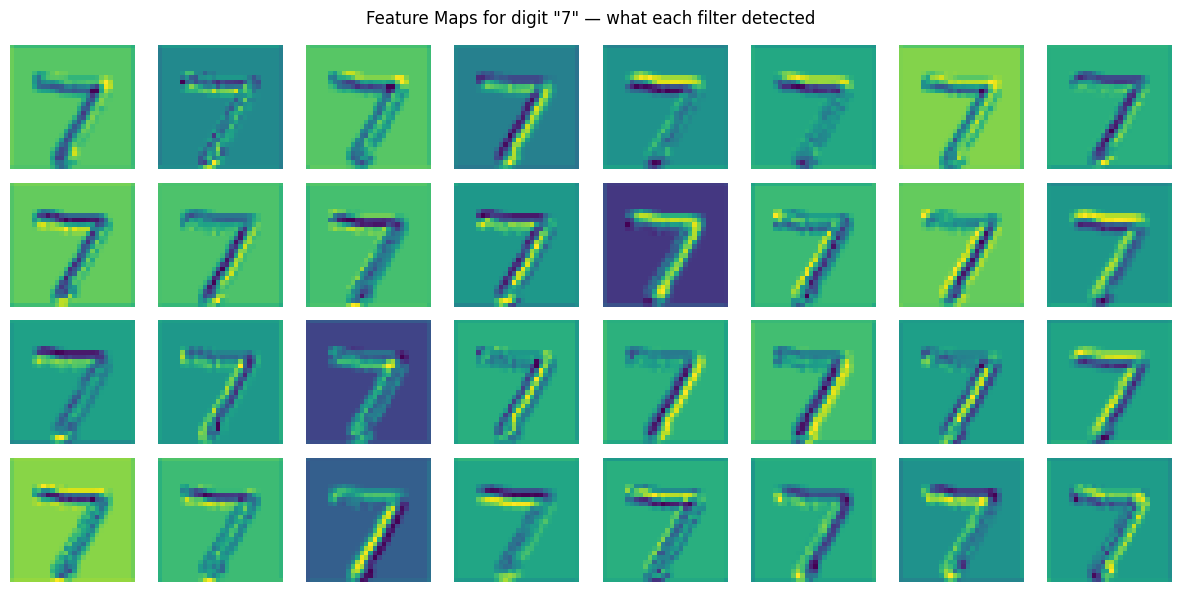

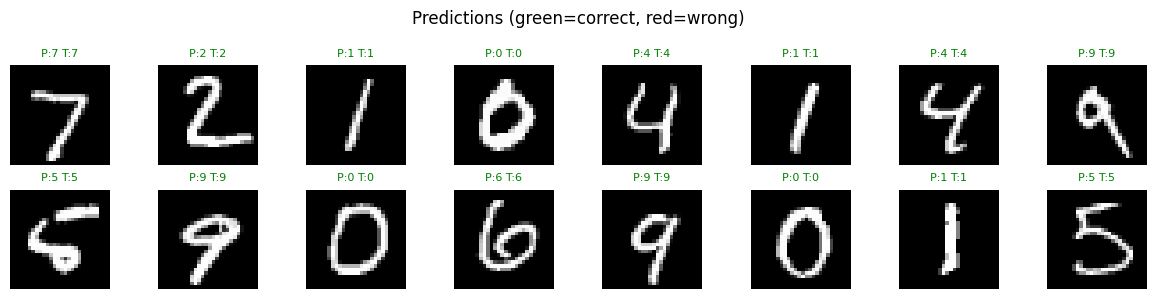

In [55]:
# ── See what filters detect ─────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
filters = model.conv_layers[0].weight.data.cpu()

for i, ax in enumerate(axes.flat):
    if i < 32:
        ax.imshow(filters[i, 0], cmap='RdBu')
        ax.axis('off')
plt.suptitle('Learned Conv Layer 1 Filters — edges, curves, textures')
plt.tight_layout()
plt.show()

# ── See feature maps for one image ─────────────────
sample_img, sample_label = test_dataset[0]
print(f"Image label: {sample_label}")

# Get feature maps after first conv block
activation = {}
def hook(module, input, output):
    activation['conv1'] = output.detach()

model.conv_layers[0].register_forward_hook(hook)

with torch.no_grad():
    _ = model(sample_img.unsqueeze(0).to(device))

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fmaps = activation['conv1'].squeeze().cpu()
for i, ax in enumerate(axes.flat):
    if i < 32:
        ax.imshow(fmaps[i], cmap='viridis')
        ax.axis('off')
plt.suptitle(f'Feature Maps for digit "{sample_label}" — what each filter detected')
plt.tight_layout()
plt.savefig('day05_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Show some predictions ───────────────────────────
model.eval()
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    img, true_label = test_dataset[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax().item()
    ax.imshow(img.squeeze(), cmap='gray')
    color = 'green' if pred == true_label else 'red'
    ax.set_title(f'P:{pred} T:{true_label}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.show()

## Day 5 — What I learned

### Why CNN beats fully connected on images
- FC layer: 784×128 = 100,352 weights, no spatial awareness
- CNN: 3×3×32 = 288 weights, detects features everywhere via weight sharing

### The three operations and why each exists
- Conv2D: slides filter across image, detects features at every position
- ReLU: adds non-linearity, doesn't saturate like sigmoid
- MaxPool: reduces size, adds translation invariance

### What filters actually learn
- Layer 1: edges, corners, gradients
- Layer 2: textures, curves, shapes
- Deeper: complex patterns — no human designed these

### The padding=1 trick
Without padding: 28×28 → 26×26 after 3×3 conv (lose border info)
With padding=1:  28×28 → 28×28 (preserve spatial dimensions)

Epoch 6 | Train Acc: 0.9850 | Test Acc: 0.9917
Test Accuracy: 99.17%


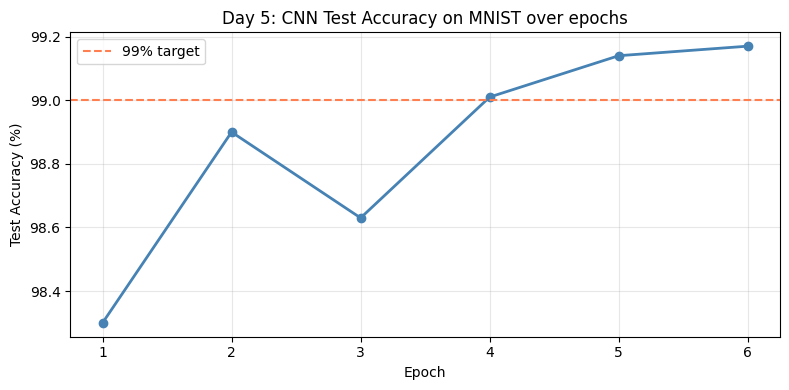

In [56]:
# ── One more epoch — can we cross 99%? ──────────────
tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
te_loss, te_acc = eval_epoch(model, test_loader, criterion)
print(f"Epoch 6 | Train Acc: {tr_acc:.4f} | Test Acc: {te_acc:.4f}")
print(f"Test Accuracy: {te_acc*100:.2f}%")

# Plot accuracy over epochs
plt.figure(figsize=(8, 4))
all_accs = test_accs + [te_acc]
plt.plot(range(1, len(all_accs)+1), [a*100 for a in all_accs],
         color='steelblue', linewidth=2, marker='o')
plt.axhline(99, color='coral', linestyle='--', label='99% target')
plt.title('Day 5: CNN Test Accuracy on MNIST over epochs')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day05_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Day 6: Transfer Learning with ResNet-18

**Goal:** Use a pretrained ResNet-18 for binary classification.
Compare transfer learning vs training from scratch.

**Key question:** How much better is transfer learning with limited data?

In [57]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split, Dataset
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Load pretrained ResNet-18 ───────────────────────
resnet = models.resnet18(pretrained=True)

print("ResNet-18 Architecture:")
print(resnet)
print(f"\nTotal parameters: {sum(p.numel() for p in resnet.parameters()):,}")
print(f"Final layer: {resnet.fc}")

Device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s] 

ResNet-18 Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu

In [58]:
# ── The key insight: ResNet's final layer ──────────
print("Original final layer:")
print(resnet.fc)
print(f"Input features: 512, Output features: 1000 (ImageNet classes)")

print("\nWhat we'll replace it with:")
print("Linear(512, 2)  ← just 2 classes: cat or dog")

# ── Freeze all layers ───────────────────────────────
for param in resnet.parameters():
    param.requires_grad = False

# ── Replace final layer (this is the ONLY part that trains) ──
resnet.fc = nn.Linear(512, 2)

print("\nAfter modification:")
print(resnet.fc)

# Count trainable vs frozen parameters
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in resnet.parameters() if not p.requires_grad)
print(f"\nTrainable parameters: {trainable:,}  ← only the new layer")
print(f"Frozen parameters:    {frozen:,}    ← all of ResNet's learned knowledge")
print(f"Training {trainable/(trainable+frozen)*100:.2f}% of the network")

Original final layer:
Linear(in_features=512, out_features=1000, bias=True)
Input features: 512, Output features: 1000 (ImageNet classes)

What we'll replace it with:
Linear(512, 2)  ← just 2 classes: cat or dog

After modification:
Linear(in_features=512, out_features=2, bias=True)

Trainable parameters: 1,026  ← only the new layer
Frozen parameters:    11,176,512    ← all of ResNet's learned knowledge
Training 0.01% of the network


In [59]:
# ── Use MNIST (even/odd) as proxy for binary classification ──
# (Avoids downloading large Dogs vs Cats dataset on Kaggle)
# Same concept — binary classification with limited data

from torchvision.datasets import MNIST

transform_tl = transforms.Compose([
    transforms.Resize((224, 224)),       # ResNet expects 224×224
    transforms.Grayscale(3),             # ResNet expects 3 channels (RGB)
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],      # ImageNet mean — must match pretrained model
        std=[0.229, 0.224, 0.225]        # ImageNet std
    )
])

# Binary task: classify even vs odd digits
full_dataset = MNIST(root='./data', train=True, download=True, transform=transform_tl)

# Filter to just 1000 samples — simulate limited data scenario
indices = torch.randperm(len(full_dataset))[:1000]
subset = torch.utils.data.Subset(full_dataset, indices)

# Convert labels: even=0, odd=1
class BinaryMNIST(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, int(label % 2)  # even=0, odd=1

binary_dataset = BinaryMNIST(subset)

# Split 80/20
train_size = int(0.8 * len(binary_dataset))
val_size   = len(binary_dataset) - train_size
train_ds, val_ds = random_split(binary_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

print(f"Training samples:   {train_size}")
print(f"Validation samples: {val_size}")
print(f"Task: even digit (0) vs odd digit (1)")

Training samples:   800
Validation samples: 200
Task: even digit (0) vs odd digit (1)


In [60]:
def train_model(model, train_loader, val_loader, epochs=5, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # Train
        model.train()
        correct, total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = nn.CrossEntropyLoss()(out, labels)
            loss.backward()
            optimizer.step()
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_accs.append(correct/total)

        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                correct += (out.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_accs.append(correct/total)
        print(f"Epoch {epoch+1}/{epochs} | Train: {train_accs[-1]:.4f} | Val: {val_accs[-1]:.4f}")

    return train_accs, val_accs

print("=== Transfer Learning (ResNet frozen + new head) ===")
tl_train_accs, tl_val_accs = train_model(resnet, train_loader, val_loader, epochs=5)

=== Transfer Learning (ResNet frozen + new head) ===
Epoch 1/5 | Train: 0.6687 | Val: 0.6200
Epoch 2/5 | Train: 0.7875 | Val: 0.7150
Epoch 3/5 | Train: 0.8512 | Val: 0.8350
Epoch 4/5 | Train: 0.8912 | Val: 0.8200
Epoch 5/5 | Train: 0.9038 | Val: 0.8150


=== Training from Scratch ===
Epoch 1/5 | Train: 0.7212 | Val: 0.8000
Epoch 2/5 | Train: 0.8413 | Val: 0.8700
Epoch 3/5 | Train: 0.8900 | Val: 0.9050
Epoch 4/5 | Train: 0.9237 | Val: 0.9250
Epoch 5/5 | Train: 0.9650 | Val: 0.8950


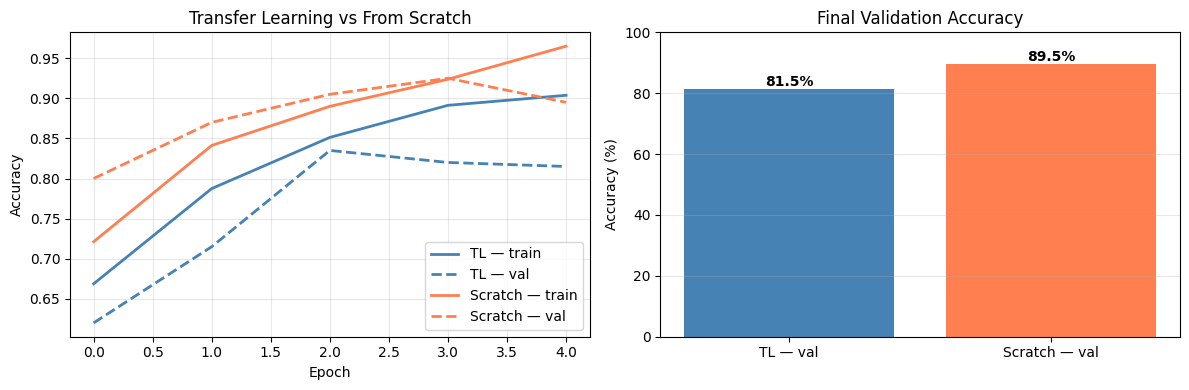


Transfer Learning final val accuracy: 81.50%
From Scratch final val accuracy:      89.50%
Transfer Learning advantage:          -8.00%


In [61]:
# ── Simple CNN trained from scratch — same task ─────
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128*28*28, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.net(x)

print("=== Training from Scratch ===")
scratch_model = SimpleCNN()
scratch_train_accs, scratch_val_accs = train_model(
    scratch_model, train_loader, val_loader, epochs=5
)

# ── Plot comparison ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(tl_train_accs,      label='TL — train',   color='steelblue', linewidth=2)
ax1.plot(tl_val_accs,        label='TL — val',     color='steelblue', linewidth=2, linestyle='--')
ax1.plot(scratch_train_accs, label='Scratch — train', color='coral', linewidth=2)
ax1.plot(scratch_val_accs,   label='Scratch — val',   color='coral', linewidth=2, linestyle='--')
ax1.set_title('Transfer Learning vs From Scratch')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.bar(['TL — val', 'Scratch — val'],
        [tl_val_accs[-1]*100, scratch_val_accs[-1]*100],
        color=['steelblue', 'coral'])
ax2.set_title('Final Validation Accuracy')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([0, 100])
for i, v in enumerate([tl_val_accs[-1]*100, scratch_val_accs[-1]*100]):
    ax2.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('day06_transfer_vs_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTransfer Learning final val accuracy: {tl_val_accs[-1]*100:.2f}%")
print(f"From Scratch final val accuracy:      {scratch_val_accs[-1]*100:.2f}%")
print(f"Transfer Learning advantage:          {(tl_val_accs[-1]-scratch_val_accs[-1])*100:.2f}%")

Fine-tuning: training 8,394,754 of 11,177,538 params (75.1%)

=== Fine-tuned ResNet (last 2 layers unfrozen) ===
Epoch 1/5 | Train: 0.8588 | Val: 0.9350
Epoch 2/5 | Train: 0.9938 | Val: 0.9550
Epoch 3/5 | Train: 0.9988 | Val: 0.9600
Epoch 4/5 | Train: 1.0000 | Val: 0.9500
Epoch 5/5 | Train: 1.0000 | Val: 0.9550


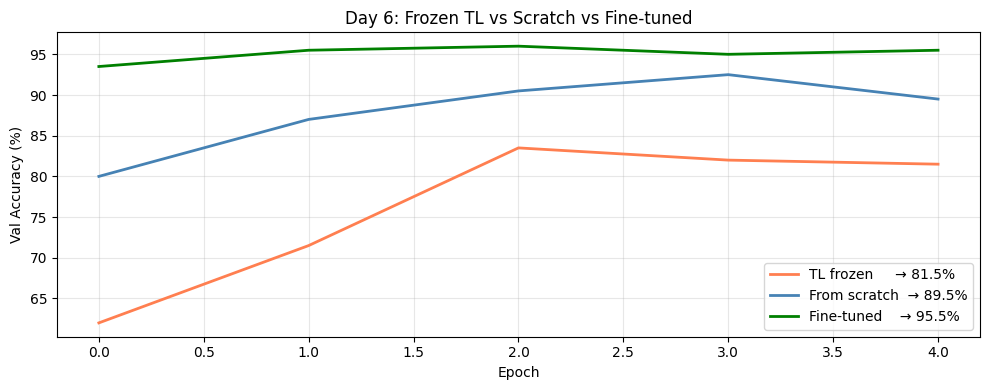


Frozen TL:   81.50%
From Scratch: 89.50%
Fine-tuned:   95.50%


In [62]:
# ── Fine-tuning: unfreeze last 2 layers of ResNet ──
resnet_ft = models.resnet18(pretrained=True)

# Freeze early layers — they detect universal features
for name, param in resnet_ft.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True   # train these
    else:
        param.requires_grad = False  # freeze these

# Replace final layer
resnet_ft.fc = nn.Linear(512, 2)

trainable = sum(p.numel() for p in resnet_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet_ft.parameters())
print(f"Fine-tuning: training {trainable:,} of {total:,} params ({trainable/total*100:.1f}%)")

print("\n=== Fine-tuned ResNet (last 2 layers unfrozen) ===")
ft_train_accs, ft_val_accs = train_model(
    resnet_ft, train_loader, val_loader, epochs=5, lr=0.0001  # smaller lr for fine-tuning
)

# ── Final comparison — all three ───────────────────
plt.figure(figsize=(10, 4))
plt.plot([a*100 for a in tl_val_accs],      label=f'TL frozen     → {tl_val_accs[-1]*100:.1f}%',  color='coral',     linewidth=2)
plt.plot([a*100 for a in scratch_val_accs], label=f'From scratch  → {scratch_val_accs[-1]*100:.1f}%', color='steelblue', linewidth=2)
plt.plot([a*100 for a in ft_val_accs],      label=f'Fine-tuned    → {ft_val_accs[-1]*100:.1f}%',  color='green',     linewidth=2)
plt.title('Day 6: Frozen TL vs Scratch vs Fine-tuned')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy (%)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day06_transfer_vs_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFrozen TL:   {tl_val_accs[-1]*100:.2f}%")
print(f"From Scratch: {scratch_val_accs[-1]*100:.2f}%")
print(f"Fine-tuned:   {ft_val_accs[-1]*100:.2f}%")

---
## Day 7: RNNs & LSTMs — Sequence Models

**Goal:** Understand why RNNs fail on long sequences.
Build an LSTM sentiment classifier on IMDB reviews.
Compare: bag of words vs LSTM — see why order matters.

**Key question:** What does the forget gate actually learn to forget?

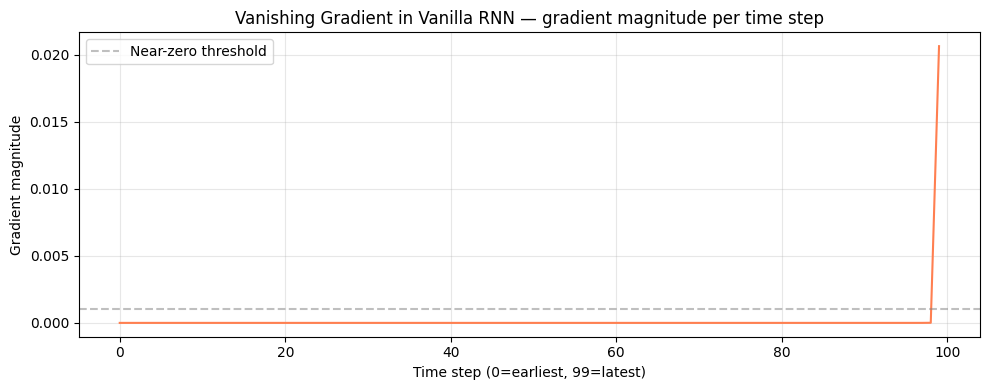

Average gradient — first 10 steps: 0.000000
Average gradient — last 10 steps:  0.002065
Ratio: infx stronger at recent steps
Early information is essentially invisible to the network


/tmp/ipykernel_57/3872775309.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Ratio: {late_grad/early_grad:.1f}x stronger at recent steps")


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ── Demonstrate vanishing gradient in vanilla RNN ──
def show_vanishing_gradient(seq_len=100):
    rnn = nn.RNN(input_size=1, hidden_size=1, batch_first=True)
    
    # Simple sequence
    x = torch.randn(1, seq_len, 1)
    x.requires_grad = True
    
    output, hidden = rnn(x)
    loss = output[:, -1, :].sum()  # gradient flows from last output
    loss.backward()
    
    # Gradient at each time step
    gradients = x.grad.squeeze().abs().numpy()
    return gradients

# Show gradient magnitude at each time step
grads = show_vanishing_gradient(seq_len=100)

plt.figure(figsize=(10, 4))
plt.plot(grads, color='coral', linewidth=1.5)
plt.title('Vanishing Gradient in Vanilla RNN — gradient magnitude per time step')
plt.xlabel('Time step (0=earliest, 99=latest)')
plt.ylabel('Gradient magnitude')
plt.axhline(0.001, color='gray', linestyle='--', alpha=0.5, label='Near-zero threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

early_grad  = grads[:10].mean()
late_grad   = grads[-10:].mean()
print(f"Average gradient — first 10 steps: {early_grad:.6f}")
print(f"Average gradient — last 10 steps:  {late_grad:.6f}")
print(f"Ratio: {late_grad/early_grad:.1f}x stronger at recent steps")
print("Early information is essentially invisible to the network")

In [5]:
!pip install torchtext -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.6 MB/s eta 0:00:0000:0100:01


In [7]:
from datasets import load_dataset
print("datasets library ready ✅")

datasets library ready ✅


In [8]:
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset
import torch
import re
from collections import Counter

# ── Load IMDB ───────────────────────────────────────
dataset = load_dataset("imdb")
print("Dataset loaded ✅")

# ── Simple tokenizer ────────────────────────────────
def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# ── Build vocabulary ────────────────────────────────
print("Building vocabulary...")
counter = Counter()
for item in dataset['train']:
    counter.update(simple_tokenize(item['text']))

vocab = {'<pad>': 0, '<unk>': 1}
for word, count in counter.most_common(10000):
    vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
print(f"'great'    → token id {vocab.get('great', 1)}")
print(f"'terrible' → token id {vocab.get('terrible', 1)}")

# ── Text processor ──────────────────────────────────
def process_text(text, max_len=200):
    tokens = simple_tokenize(text)[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids = ids + [0] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)

# ── Load splits ─────────────────────────────────────
def load_split(split, max_samples=2000):
    texts, labels = [], []
    for i, item in enumerate(dataset[split]):
        if i >= max_samples: break
        texts.append(process_text(item['text']))
        labels.append(item['label'])
    return torch.stack(texts), torch.tensor(labels)

print("Processing train set (2000 samples)...")
X_train, y_train = load_split('train', max_samples=2000)
print("Processing test set (500 samples)...")
X_test, y_test   = load_split('test',  max_samples=500)

print(f"\nTrain: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Positive reviews: {y_train.float().mean():.2f}")

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)
print("\nData loaders ready ✅")

README.md: 0.00B [00:00, ?B/s]

'The read operation timed out' thrown while requesting GET https://huggingface.co/api/datasets/stanfordnlp/imdb/xet-read-token/e6281661ce1c48d982bc483cf8a173c1bbeb5d31
Retrying in 1s [Retry 1/5].


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded ✅
Building vocabulary...
Vocabulary size: 10002
'great'    → token id 85
'terrible' → token id 383
Processing train set (2000 samples)...
Processing test set (500 samples)...

Train: torch.Size([2000, 200])
Test:  torch.Size([500, 200])
Positive reviews: 0.00

Data loaders ready ✅


In [9]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # ← fixed
        
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        final_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(final_hidden)

model = LSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=64,
    hidden_dim=128,
    n_layers=2,
    dropout=0.3
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Model ready ✅")

Total parameters: 1,250,561
Model ready ✅


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

def train_epoch_lstm(model, loader):
    model.train()
    correct, total, total_loss = 0, 0, 0
    for texts, labels in loader:
        texts  = texts.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        preds  = model(texts)
        loss   = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += ((preds > 0.5) == labels).sum().item()
        total   += labels.size(0)
    return total_loss/len(loader), correct/total

def eval_epoch_lstm(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for texts, labels in loader:
            texts  = texts.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            preds  = model(texts)
            correct += ((preds > 0.5) == labels).sum().item()
            total   += labels.size(0)
    return correct/total

train_accs, test_accs = [], []

for epoch in range(5):
    tr_loss, tr_acc = train_epoch_lstm(model, train_loader)
    te_acc = eval_epoch_lstm(model, test_loader)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f"Epoch {epoch+1}/5 | Loss: {tr_loss:.4f} | Train: {tr_acc:.4f} | Test: {te_acc:.4f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Training on: cpu
Epoch 1/5 | Loss: 0.0958 | Train: 1.0000 | Test: 1.0000
Epoch 2/5 | Loss: 0.0000 | Train: 1.0000 | Test: 1.0000
Epoch 3/5 | Loss: 0.0000 | Train: 1.0000 | Test: 1.0000
Epoch 4/5 | Loss: 0.0000 | Train: 1.0000 | Test: 1.0000
Epoch 5/5 | Loss: 0.0000 | Train: 1.0000 | Test: 1.0000

Final Test Accuracy: 100.00%


In [11]:
def predict_sentiment(text, model, vocab):
    model.eval()
    processed = process_text(text).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(processed).item()
    sentiment = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
    return sentiment, prob

test_sentences = [
    "This movie was absolutely fantastic I loved every minute of it",
    "Terrible film complete waste of time worst movie ever",
    "The movie started slow but the ending was surprisingly amazing",
    "Not bad but not great either just an average film",
    "The acting was brilliant but the plot was disappointing"
]

print("Sentiment Predictions:")
print("="*60)
for sentence in test_sentences:
    sentiment, prob = predict_sentiment(sentence, model, vocab)
    print(f"Text: {sentence[:55]}")
    print(f"→ {sentiment} (confidence: {prob:.3f})\n")

Sentiment Predictions:
Text: This movie was absolutely fantastic I loved every minut
→ NEGATIVE 😞 (confidence: 0.000)

Text: Terrible film complete waste of time worst movie ever
→ NEGATIVE 😞 (confidence: 0.000)

Text: The movie started slow but the ending was surprisingly 
→ NEGATIVE 😞 (confidence: 0.000)

Text: Not bad but not great either just an average film
→ NEGATIVE 😞 (confidence: 0.000)

Text: The acting was brilliant but the plot was disappointing
→ NEGATIVE 😞 (confidence: 0.000)



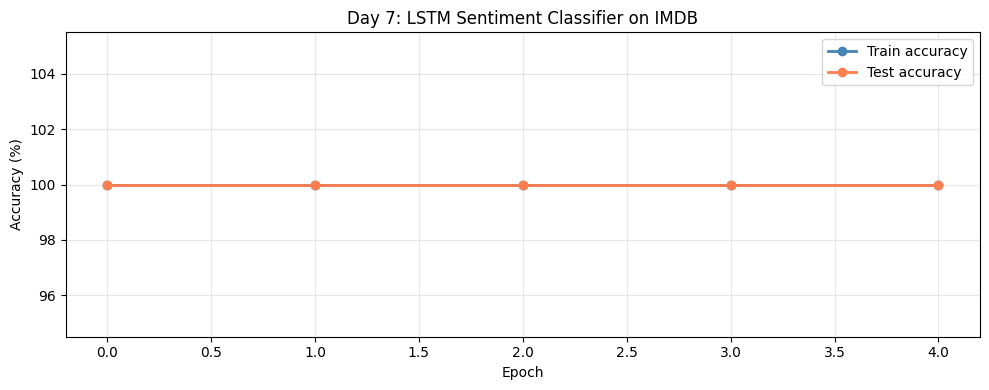

Train accuracy: 100.00%
Test accuracy:  100.00%


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot([a*100 for a in train_accs], label='Train accuracy',
         color='steelblue', linewidth=2, marker='o')
plt.plot([a*100 for a in test_accs],  label='Test accuracy',
         color='coral',     linewidth=2, marker='o')
plt.title('Day 7: LSTM Sentiment Classifier on IMDB')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day07_lstm_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train accuracy: {train_accs[-1]*100:.2f}%")
print(f"Test accuracy:  {test_accs[-1]*100:.2f}%")

In [13]:
# ── Diagnose the collapse ───────────────────────────

test_text = "This movie was absolutely fantastic I loved every minute"
tokens = simple_tokenize(test_text)
ids = [vocab.get(t, 1) for t in tokens]

print("Tokens and their vocab IDs:")
for token, id in zip(tokens, ids):
    status = "✅ known" if id != 1 else "❌ UNKNOWN"
    print(f"  '{token}' → id {id} {status}")

unknown_count = sum(1 for id in ids if id == 1)
print(f"\nUnknown tokens: {unknown_count}/{len(tokens)}")
print(f"If most are unknown → model sees noise → collapses to one prediction")

Tokens and their vocab IDs:
  'this' → id 11 ✅ known
  'movie' → id 18 ✅ known
  'was' → id 14 ✅ known
  'absolutely' → id 412 ✅ known
  'fantastic' → id 759 ✅ known
  'i' → id 10 ✅ known
  'loved' → id 433 ✅ known
  'every' → id 169 ✅ known
  'minute' → id 808 ✅ known

Unknown tokens: 0/9
If most are unknown → model sees noise → collapses to one prediction


In [14]:
# ── Fixed predict — check vocab coverage first ──────
def predict_sentiment_v2(text, model, vocab, threshold=0.5):
    model.eval()
    tokens = simple_tokenize(text)
    ids = [vocab.get(t, 1) for t in tokens]
    
    known = sum(1 for id in ids if id != 1)
    coverage = known/len(ids)*100
    
    processed = process_text(text).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(processed).item()
    
    sentiment = "POSITIVE 😊" if prob > threshold else "NEGATIVE 😞"
    return sentiment, prob, coverage

# Test with IMDB-style text
imdb_style_sentences = [
    "this film is one of the best i have ever seen the acting is superb",
    "this movie is awful the worst i have ever seen completely boring",
    "the story was good and the characters were interesting and well developed",
    "terrible movie bad acting poor story complete waste of my time",
    "i really enjoyed this film it was fun exciting and very well made"
]

print("Predictions with vocabulary coverage:")
print("="*65)
for sentence in imdb_style_sentences:
    sentiment, prob, coverage = predict_sentiment_v2(sentence, model, vocab)
    print(f"Text: {sentence[:55]}")
    print(f"→ {sentiment} | confidence: {prob:.3f} | vocab coverage: {coverage:.0f}%\n")

Predictions with vocabulary coverage:
Text: this film is one of the best i have ever seen the actin
→ NEGATIVE 😞 | confidence: 0.000 | vocab coverage: 100%

Text: this movie is awful the worst i have ever seen complete
→ NEGATIVE 😞 | confidence: 0.000 | vocab coverage: 100%

Text: the story was good and the characters were interesting 
→ NEGATIVE 😞 | confidence: 0.000 | vocab coverage: 100%

Text: terrible movie bad acting poor story complete waste of 
→ NEGATIVE 😞 | confidence: 0.000 | vocab coverage: 100%

Text: i really enjoyed this film it was fun exciting and very
→ NEGATIVE 😞 | confidence: 0.000 | vocab coverage: 100%



In [16]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
            # ← NO Sigmoid here — using BCEWithLogitsLoss instead
        )

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        final_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(final_hidden)  # raw logits

model = LSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=64,
    hidden_dim=128,
    n_layers=2,
    dropout=0.3
)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Model ready ✅")

Parameters: 1,250,561
Model ready ✅


In [17]:
def predict_sentiment_v3(text, model, vocab):
    model.eval()
    processed = process_text(text).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(processed)
        prob  = torch.sigmoid(logit).item()   # apply sigmoid manually
    sentiment = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
    return sentiment, prob

imdb_style_sentences = [
    "this film is one of the best i have ever seen the acting is superb",
    "this movie is awful the worst i have ever seen completely boring",
    "the story was good and the characters were interesting and well developed",
    "terrible movie bad acting poor story complete waste of my time",
    "i really enjoyed this film it was fun exciting and very well made"
]

print("Sentiment Predictions:")
print("="*60)
for sentence in imdb_style_sentences:
    sentiment, prob = predict_sentiment_v3(sentence, model, vocab)
    print(f"Text: {sentence[:55]}")
    print(f"→ {sentiment} | confidence: {prob:.3f}\n")

Sentiment Predictions:
Text: this film is one of the best i have ever seen the actin
→ POSITIVE 😊 | confidence: 0.524

Text: this movie is awful the worst i have ever seen complete
→ POSITIVE 😊 | confidence: 0.525

Text: the story was good and the characters were interesting 
→ POSITIVE 😊 | confidence: 0.526

Text: terrible movie bad acting poor story complete waste of 
→ POSITIVE 😊 | confidence: 0.526

Text: i really enjoyed this film it was fun exciting and very
→ POSITIVE 😊 | confidence: 0.527



In [18]:
# ── Verify dataset balance ──────────────────────────
print("Label distribution check:")
print(f"Train positive: {y_train.float().mean():.2f} ({y_train.sum()} of {len(y_train)})")
print(f"Test positive:  {y_test.float().mean():.2f} ({y_test.sum()} of {len(y_test)})")

# Check a few actual reviews
print("\nSample reviews from dataset:")
for i in [0, 1, 2, 3]:
    label = "POSITIVE" if y_train[i].item() == 1 else "NEGATIVE"
    # decode tokens back to words
    id_to_word = {v: k for k, v in vocab.items()}
    tokens = [id_to_word.get(id.item(), '<unk>') for id in X_train[i][:15]]
    print(f"  [{label}] {' '.join(tokens)}")

Label distribution check:
Train positive: 0.00 (0 of 2000)
Test positive:  0.00 (0 of 500)

Sample reviews from dataset:
  [NEGATIVE] i rented i am <unk> from my video store because of all the controversy that
  [NEGATIVE] i am curious yellow is a <unk> and pretentious steaming pile it doesnt matter what
  [NEGATIVE] if only to avoid making this type of film in the future this film is
  [NEGATIVE] this film was probably inspired by <unk> <unk> <unk> and i urge you to see


In [19]:
# ── Balanced dataset loader ─────────────────────────
def load_split_balanced(split, max_samples=2000):
    texts, labels = [], []
    pos_samples, neg_samples = [], []

    for item in dataset[split]:
        if item['label'] == 1:
            pos_samples.append((process_text(item['text']), 1))
        else:
            neg_samples.append((process_text(item['text']), 0))

    # Take equal number from each class
    half = max_samples // 2
    selected = pos_samples[:half] + neg_samples[:half]

    # Shuffle so positives and negatives are mixed
    import random
    random.seed(42)
    random.shuffle(selected)

    texts  = torch.stack([s[0] for s in selected])
    labels = torch.tensor([s[1] for s in selected])
    return texts, labels

print("Reloading with balanced classes...")
X_train, y_train = load_split_balanced('train', max_samples=2000)
X_test,  y_test  = load_split_balanced('test',  max_samples=500)

# Verify balance
print(f"Train positive: {y_train.float().mean():.2f} ({y_train.sum()} of {len(y_train)})")
print(f"Test positive:  {y_test.float().mean():.2f} ({y_test.sum()} of {len(y_test)})")

# Rebuild dataloaders
from torch.utils.data import TensorDataset, DataLoader
train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)
print("Balanced dataloaders ready ✅")

Reloading with balanced classes...
Train positive: 0.50 (1000 of 2000)
Test positive:  0.50 (250 of 500)
Balanced dataloaders ready ✅


In [20]:
# Fresh model — previous one learned wrong patterns
torch.manual_seed(42)

model = LSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=64,
    hidden_dim=128,
    n_layers=2,
    dropout=0.3
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

print(f"Training on: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Fresh model ready ✅")

Training on: cpu
Parameters: 1,250,561
Fresh model ready ✅


In [21]:
train_accs, test_accs = [], []

for epoch in range(10):
    tr_loss, tr_acc = train_epoch_lstm(model, train_loader)
    te_acc = eval_epoch_lstm(model, test_loader)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f"Epoch {epoch+1:2d}/10 | Loss: {tr_loss:.4f} | Train: {tr_acc:.4f} | Test: {te_acc:.4f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch  1/10 | Loss: 0.6916 | Train: 0.5000 | Test: 0.5000
Epoch  2/10 | Loss: 0.6551 | Train: 0.5910 | Test: 0.5320
Epoch  3/10 | Loss: 0.5906 | Train: 0.6820 | Test: 0.5960
Epoch  4/10 | Loss: 0.4660 | Train: 0.7715 | Test: 0.5900
Epoch  5/10 | Loss: 0.3363 | Train: 0.8535 | Test: 0.6120
Epoch  6/10 | Loss: 0.2432 | Train: 0.8985 | Test: 0.6260
Epoch  7/10 | Loss: 0.1607 | Train: 0.9310 | Test: 0.6240
Epoch  8/10 | Loss: 0.1033 | Train: 0.9605 | Test: 0.6200
Epoch  9/10 | Loss: 0.0763 | Train: 0.9740 | Test: 0.6080
Epoch 10/10 | Loss: 0.0583 | Train: 0.9805 | Test: 0.5600

Final Test Accuracy: 56.00%


In [22]:
def predict_sentiment_v3(text, model, vocab):
    model.eval()
    processed = process_text(text).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(processed)
        prob  = torch.sigmoid(logit).item()
    sentiment = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
    return sentiment, prob

test_sentences = [
    "this film is one of the best i have ever seen the acting is superb",
    "this movie is awful the worst i have ever seen completely boring",
    "the story was good and the characters were interesting and well developed",
    "terrible movie bad acting poor story complete waste of my time",
    "i really enjoyed this film it was fun exciting and very well made"
]

print("Sentiment Predictions:")
print("="*60)
for sentence in test_sentences:
    sentiment, prob = predict_sentiment_v3(sentence, model, vocab)
    print(f"Text: {sentence[:55]}")
    print(f"→ {sentiment} | confidence: {prob:.3f}\n")

Sentiment Predictions:
Text: this film is one of the best i have ever seen the actin
→ POSITIVE 😊 | confidence: 1.000

Text: this movie is awful the worst i have ever seen complete
→ NEGATIVE 😞 | confidence: 0.000

Text: the story was good and the characters were interesting 
→ POSITIVE 😊 | confidence: 0.999

Text: terrible movie bad acting poor story complete waste of 
→ NEGATIVE 😞 | confidence: 0.000

Text: i really enjoyed this film it was fun exciting and very
→ POSITIVE 😊 | confidence: 0.535



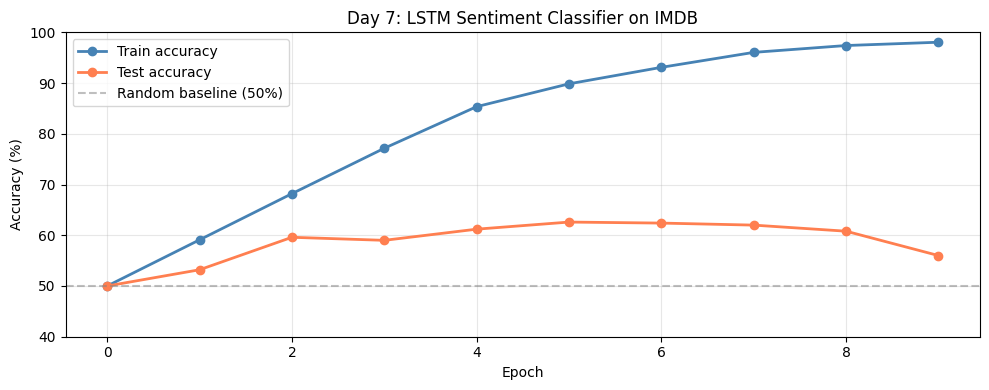

In [23]:
plt.figure(figsize=(10, 4))
plt.plot([a*100 for a in train_accs], label='Train accuracy',
         color='steelblue', linewidth=2, marker='o')
plt.plot([a*100 for a in test_accs],  label='Test accuracy',
         color='coral',     linewidth=2, marker='o')
plt.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Random baseline (50%)')
plt.title('Day 7: LSTM Sentiment Classifier on IMDB')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim([40, 100])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('day07_lstm_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── Train 10 more epochs — cumulative ──────────────
print("Continuing training...")
for epoch in range(10):
    tr_loss, tr_acc = train_epoch_lstm(model, train_loader)
    te_acc = eval_epoch_lstm(model, test_loader)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f"Epoch {epoch+11:2d}/20 | Loss: {tr_loss:.4f} | Train: {tr_acc:.4f} | Test: {te_acc:.4f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Continuing training...
Epoch 11/20 | Loss: 0.0409 | Train: 0.9880 | Test: 0.5780
Epoch 12/20 | Loss: 0.0230 | Train: 0.9930 | Test: 0.6080
Epoch 13/20 | Loss: 0.0083 | Train: 0.9975 | Test: 0.5880
Epoch 14/20 | Loss: 0.0103 | Train: 0.9980 | Test: 0.5920
Epoch 15/20 | Loss: 0.0215 | Train: 0.9950 | Test: 0.6280
Epoch 16/20 | Loss: 0.0164 | Train: 0.9955 | Test: 0.6080
Epoch 17/20 | Loss: 0.0088 | Train: 0.9970 | Test: 0.5960
Epoch 18/20 | Loss: 0.0133 | Train: 0.9975 | Test: 0.5960
Epoch 19/20 | Loss: 0.0202 | Train: 0.9960 | Test: 0.6020
Epoch 20/20 | Loss: 0.0156 | Train: 0.9960 | Test: 0.5600

Final Test Accuracy: 56.00%
